MANCA GRAFICO VARIANZE + VALORI MEDI DI Y_LAST + DISTANZA ENDTOEND IN FUNZIONE DELLA TEMPERATURA

Aggiunta dello swap ogni K block moves, K cardinalità insieme di temperature

In [16]:
import numpy as np 
import matplotlib.pyplot as plt
import random

# PARAMETERS 
N = 15  
c = 1.0  
l_min = c
l_max = 1.3 * c

temperatures = [1.2, 0.7, 0.5, 0.4, 0.3, 0.2] # beta crescenti, temperature decrescenti
epsilon = -1
h = 0.5

# Energy of the polymer 
def total_energy(polymer): 
    n=0
    for mon in polymer[1:]: # grafted monomer is not considered
        if mon[1] < h :
            n += 1
    return epsilon * n


# initial configuration of the polymer
monomers = [(0, 0)]
for i in range(1, N):  # initial vertical configuration
    distance = random.uniform(l_min, l_max)
    x_new = 0
    y_new = monomers[i - 1][1] + distance
    monomers.append((x_new, y_new))

# distances among all monomers + y > 0 constraint
def valid(index, new_mon, polymer):
    for i in range(len(polymer)):
        if new_mon[1] < 0:
            return False
        if i != index:   
            distance = ((new_mon[0] - polymer[i][0])**2 + (new_mon[1] - polymer[i][1])**2)**0.5
            if distance < c:
                return False
    return True

# distance for consecutive monomers, after the small shift
def valid_small(i, new_mon, polymer):
    d1 = ((new_mon[0] - polymer[i - 1][0])**2 + (new_mon[1] - polymer[i - 1][1])**2)**0.5
    if i + 1 < len(polymer):
        d2 = ((new_mon[0] - polymer[i + 1][0])**2 + (new_mon[1] - polymer[i + 1][1])**2)**0.5
        if d1 < l_min or d1 > l_max or d2 < l_min or d2 > l_max:
            return False
    else:
        if d1 < l_min or d1 > l_max:
            return False
    return True

# function that takes the single rotated monomer and tests if the distance with the previous rotated monomer is ok with the constraints
def valid_small_1(i, polymer):
    d1 = ((polymer[i][0] - polymer[i - 1][0])**2 + (polymer[i][1] - polymer[i - 1][1])**2)**0.5
    if i + 1 < len(polymer):
        d2 = ((polymer[i][0] - polymer[i + 1][0])**2 + (polymer[i][1] - polymer[i + 1][1])**2)**0.5
        if d1 < l_min or d1 > l_max or d2 < l_min or d2 > l_max:
            return False
    else:
        if d1 < l_min or d1 > l_max:
            return False
    return True
   
    
def test_Metropolis_shift(old, new, epsilon, T):
    valid = True
    if new[1] > h and old[1] < h:
        delta = - epsilon
        if random.random() > np.exp(- delta / T):
            valid = False
    return valid

def block_shift(polymer, T):
    for _ in range(N):
        i = random.randint(1, N - 1)
        dx, dy = np.random.normal(0, 0.15, 2)
        new_mon = (polymer[i][0] + dx, polymer[i][1] + dy)
        
        if valid(i, new_mon, polymer) and valid_small(i, new_mon, polymer):
            old_mon = polymer[i]  

            if test_Metropolis_shift(old_mon, new_mon, epsilon, T):
                polymer[i] = new_mon
            else:
                polymer[i] = old_mon  
    return polymer 
    
def block_pivot(polymer, T):
# list to store the new positions of the monomers belonging to a rotated branch
    new_branch = [] 
    
# random postion of the pivot excluding the last monomer
    j = random.randint(0, N - 2) 

    if T < 0.45:  
        angle = random.uniform(-np.pi/4, np.pi/4)
    elif T >= 0.45 and T < 0.65:
        angle = random.uniform(-np.pi/2, np.pi/2)
    else:
        angle = random.uniform(-np.pi, np.pi)
    pivot = polymer[j]
 # first element of the new branch after rotation is initialized to the pivot itself
    new_branch.append(pivot) 
    E_old, E_new = 0, 0
    
# consider each monomer located after the pivot
    for k in range(j + 1, N):
    # calculation of the enrgy before the rotation:
        if polymer[k][1] < h:
            E_old -= 1
    # new coordinates after rotation:
        x_rel, y_rel = polymer[k][0] - pivot[0], polymer[k][1] - pivot[1]
        x_rot = x_rel * np.cos(angle) - y_rel * np.sin(angle)
        y_rot = x_rel * np.sin(angle) + y_rel * np.cos(angle)
    # candidate for the new, rotated monomer:
        rot_j = (pivot[0] + x_rot, pivot[1] + y_rot) 
        new_branch.append(rot_j)         
    
    polymer1 = polymer[:j] + new_branch    
    #Verifica la validità e aggiorna E_new se rot_j è accettabile
    for k in range(j + 1, N):    
        if valid(k, polymer1[k], polymer1) and valid_small_1(k, polymer1):
            if polymer1[k][1] < h:
                E_new -= 1         
        else:
            return polymer  # discard the rotation and go back to the original polymer

    if E_new < E_old or random.random() < np.exp(-(E_new - E_old) / T):
        return polymer1 # if the rotation is accepted, return the new polymer
    return polymer # otherwise, store the original polymer




Simulation

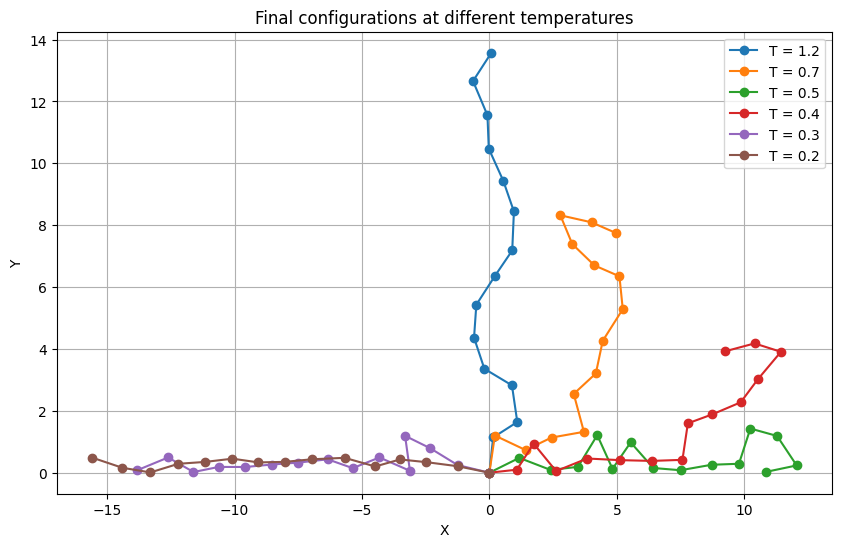

average swap rate: 34.225369%
below, the swap rate for each temperature:
[0.46163216 0.28141593 0.39279055 0.34624413 0.23469994]


In [17]:
# SIMULAZIONE 
time_steps = 50000
final_polymers = []
polymer = []
swap_ok = np.zeros(len(temperatures)-1)
swap_tries = np.zeros(len(temperatures)-1)

energies_per_T = {T: [] for T in temperatures} 
mean_energies_per_T = {T: [] for T in temperatures}
variance_mean_energy = {T: [] for T in temperatures}

Y_last = {T: [] for T in temperatures}
mean_Y_last = {T: [] for T in temperatures}
variance_mean_Y = {T: [] for T in temperatures}

sq_dist_perT = {T: [] for T in temperatures}
mean_sq_dist = {T: [] for T in temperatures}
variance_mean_sqdist = {T: [] for T in temperatures}

temperature_indices = list(range(len(temperatures))) # array of T indices  
swap_attempts, successful_swaps = 0, 0

# Creating an array of initial configurations, one for eache T
for i in range(len(temperatures)): # 
        initial = monomers.copy()
        polymer.append(initial)

for  t in range(1, time_steps + 1):
    for j in range(len(temperatures)): # For each temperature at a given time t, do the block of moves   
        T_index = temperature_indices[j]
        current_T = temperatures[j]
    # BLOCK OF MOVES
        polymer[T_index] = block_shift(polymer[T_index], current_T) 
        polymer[T_index] = block_pivot(polymer[T_index], current_T)
    
    # Coordinate y of the last monomer     
        Y = polymer[T_index][N - 1][1]
        Y_last[current_T].append(Y)
    # Energy of the polymer
        E =  total_energy(polymer[T_index]) 
        energies_per_T[current_T].append(E)
    # End-to-end square distance
        X = polymer[T_index][N-1][0] # coordinate of the last monomer
        sq_dist = (X**2 + Y**2)**0.5
        sq_dist_perT[current_T].append(sq_dist)

        
    # Every 100 steps, averaging in blocks
        if t % 100 == 0: 
        # MEAN ENERGY EVERY 100 TIME STEP
            mean_energy = sum(energies_per_T[current_T][-100:]) / 100
            mean_energies_per_T[current_T].append(mean_energy)
        # VARIANCE OF MEAN ENERGY
            mean_square_en = sum(np.array(energies_per_T[current_T][-100:])**2) / 100
            v_mean_energy = mean_square_en - mean_energy**2
            variance_mean_energy[current_T].append(v_mean_energy) 

        # MEAN last Y EVERY 100 TIME STEPS
            mean_y = sum(Y_last[current_T][-100:]) / 100
            mean_Y_last[current_T].append(mean_y)   
        # VARIANCE OF Y LAST MONOMER
            mean_square_y = sum(np.array(Y_last[current_T][-100:])**2) / 100
            v_mean_y = mean_square_y - mean_y**2
            variance_mean_Y[current_T].append(v_mean_y) 

        # MEAN Square distance EVERY 100 TIME STEP
            mean_sqdist_block = sum(sq_dist_perT[current_T][-100:]) / 100
            mean_sq_dist[current_T].append(mean_sqdist_block)   
        # VARIANCE OF square distance
            mean_square_sqdist_block = sum(np.array(sq_dist_perT[current_T][-100:])**2) / 100
            v_mean_sqdist = mean_square_sqdist_block - mean_sqdist_block**2
            variance_mean_sqdist[current_T].append(v_mean_sqdist) 


    # ------------------------------------  [  SWAP  ]  ---------------------------------------------
    # After the block of moves is done for each temperature and for some times, I try to swap 
    if t % len(temperatures) == 0:
        k = random.randint(0, len(temperatures) - 2) 
        i = temperature_indices[k] # I assign to i the index of the extracted temperature
        i_next = temperature_indices[k + 1] # i_next has the ndex of the temperature following the one extracted
        T1, T2 = temperatures[k], temperatures[k + 1] # prendi le temperature estratte
        E1, E2 = total_energy(polymer[temperature_indices[k]]), total_energy(polymer[temperature_indices[k + 1]]) 

        delta = (1 / T2 - 1 / T1) * (E2 - E1)  # assuming T2 < T1
        swap_attempts += 1 
        swap_tries[k] += 1
        if E2 > E1 or random.random() < np.exp(delta):  
            temperature_indices[k] = i_next
            temperature_indices[k+1] = i
            successful_swaps += 1
            swap_ok[k] += 1

    if t == time_steps: 
        final_polymers = [(temperatures[temperature_indices[j]], polymer[temperature_indices[j]]) for j in range(len(temperatures))]



# ---- PLOT OF FINAL CONFIGURATIONS ----
plt.figure(figsize=(10, 6))
for i, T in enumerate(temperatures):
    polymer_final = polymer[temperature_indices[i]]  # Configurazione finale del polimero per la temperatura T
    x_coords = [mon[0] for mon in polymer_final]
    y_coords = [mon[1] for mon in polymer_final]

    plt.plot(x_coords, y_coords, marker='o', label=f'T = {T}')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Final configurations at different temperatures')
plt.legend()
plt.grid()
plt.show()



# --- SWAP RATE VISUALIZATION ---
swap_rate = successful_swaps / swap_attempts if swap_attempts > 0 else 0
rate_perT = swap_ok / swap_tries
print(f"average swap rate: {swap_rate:%}")
print("below, the swap rate for each temperature:")
print(rate_perT)

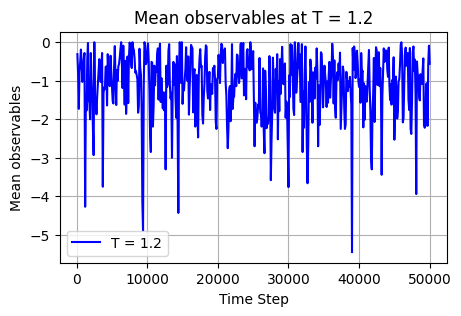

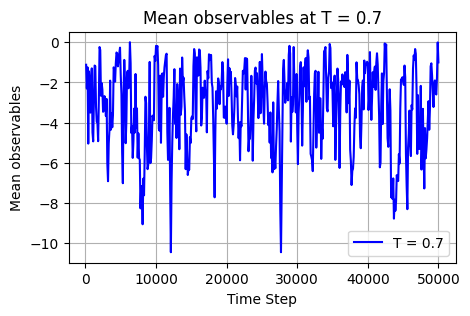

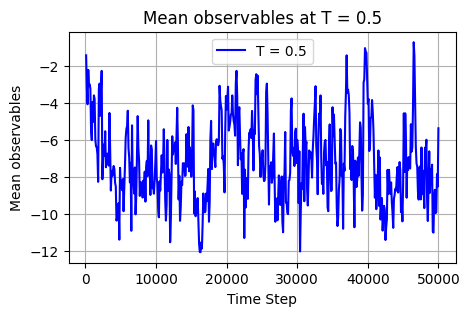

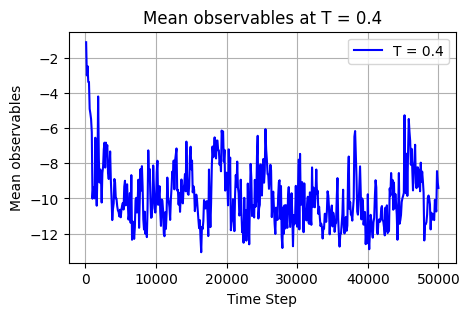

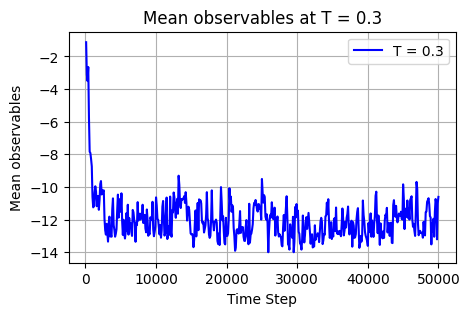

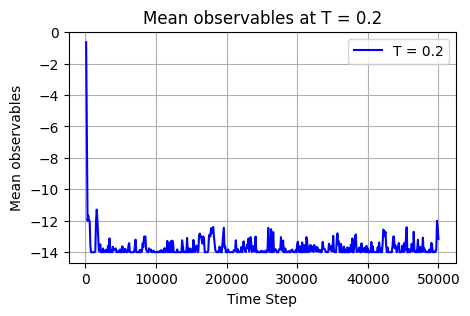

In [18]:
# ENERGY GRAPH FOR EACH TEMPERATURE
for T, mean_energies in mean_energies_per_T.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(100, time_steps + 1, 100), mean_energies, label=f'T = {T}', color='blue')
    plt.xlabel('Time Step')
    plt.ylabel('Mean observables')
    plt.title(f'Mean observables at T = {T}')
    plt.legend()
    plt.grid()
    plt.show()

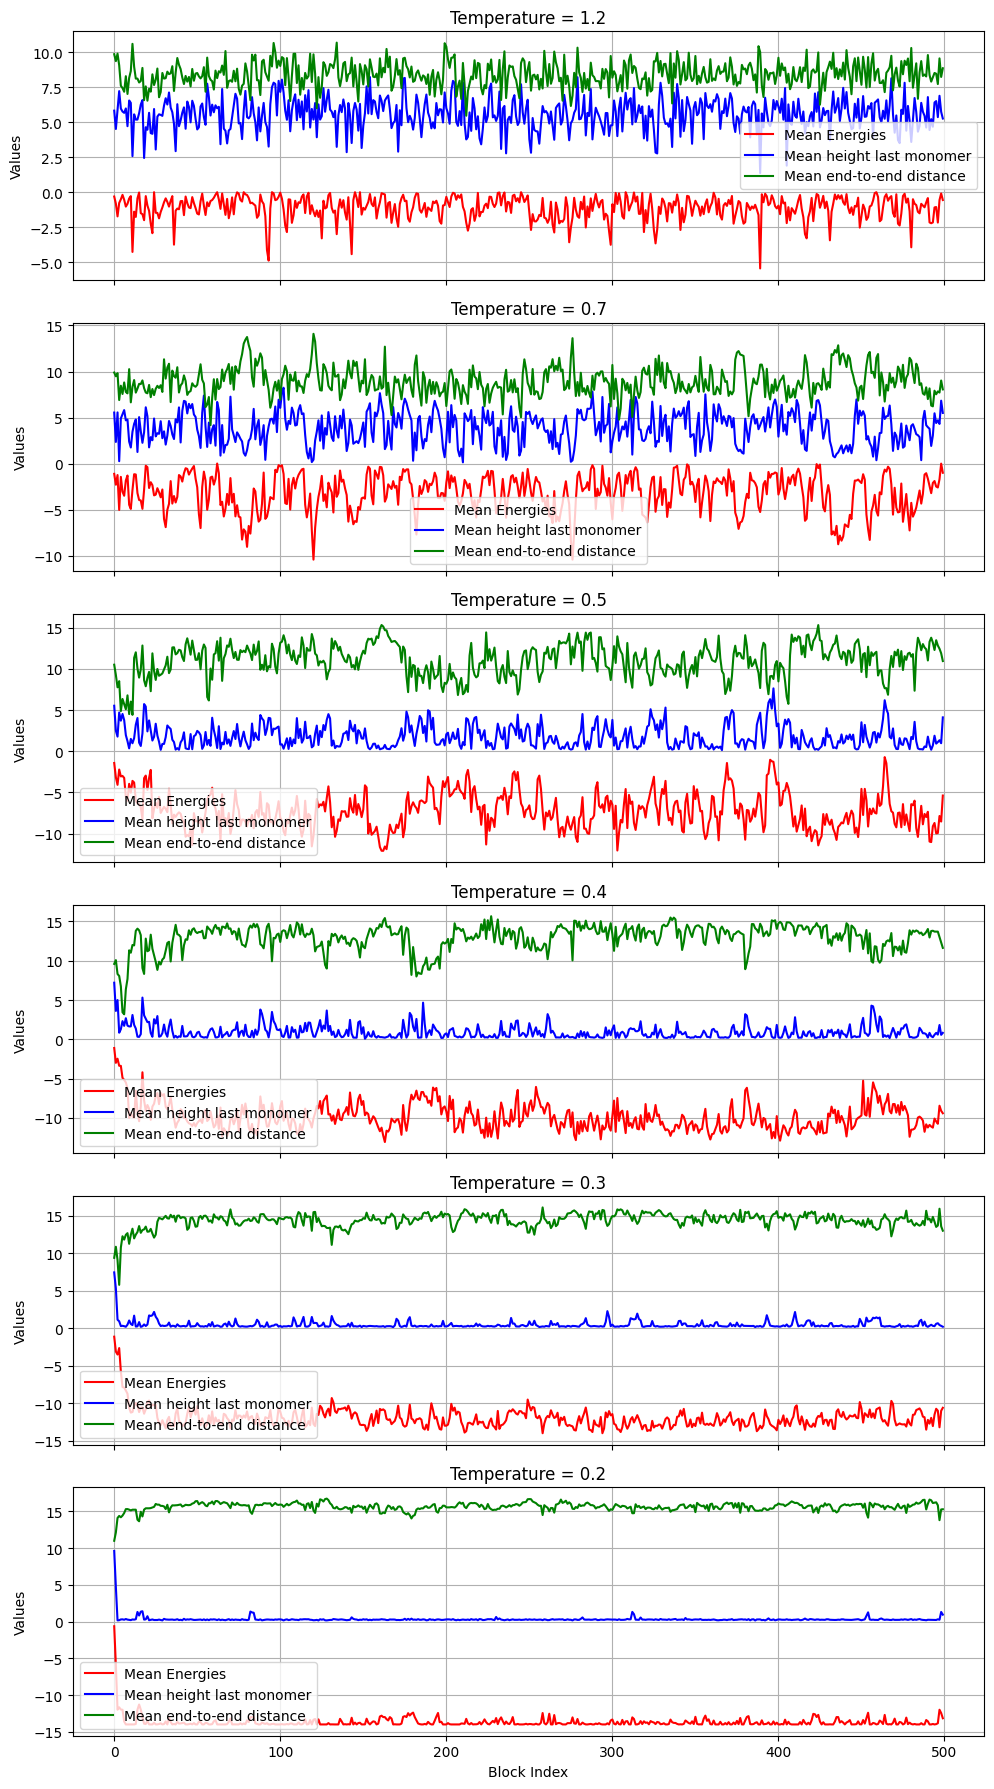

In [19]:
fig, axs = plt.subplots(len(temperatures), 1, figsize=(10, 18), sharex=True)

colors = ['red', 'blue', 'green']  
labels = ['Mean Energies', 'Mean height last monomer', 'Mean end-to-end distance']

for i, T in enumerate(temperatures):
    ax = axs[i]  
    ax.plot(mean_energies_per_T[T], color=colors[0], label=labels[0])
    ax.plot(mean_Y_last[T], color=colors[1], label=labels[1])
    ax.plot(mean_sq_dist[T], color=colors[2], label=labels[2])
    
    ax.set_title(f'Temperature = {T}')
    ax.set_ylabel('Values')
    ax.legend()
    ax.grid()

axs[-1].set_xlabel('Block Index')
plt.tight_layout()
plt.show()


Plot of the variances

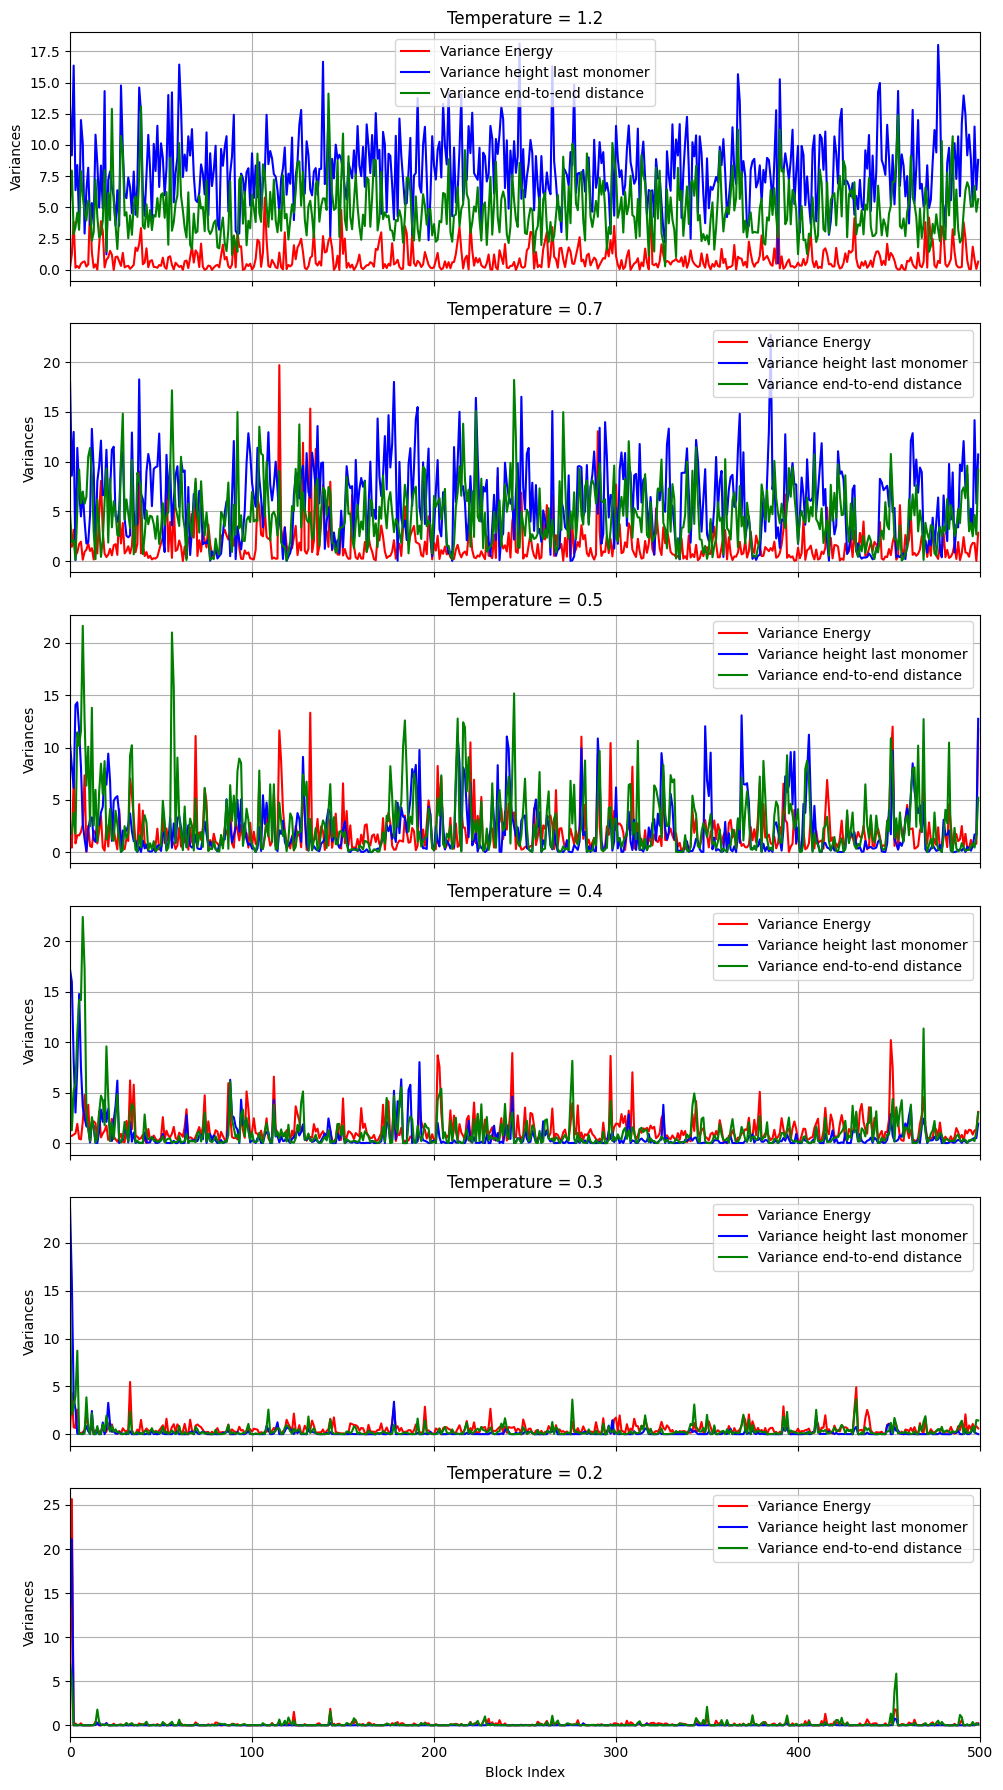

In [20]:
fig, axs = plt.subplots(len(temperatures), 1, figsize=(10, 18), sharex=True)

colors = ['red', 'blue', 'green']  
labels = ['Variance Energy', 'Variance height last monomer', 'Variance end-to-end distance']

for i, T in enumerate(temperatures):
    ax = axs[i]  
    ax.plot(variance_mean_energy[T], color=colors[0], label=labels[0])
    ax.plot(variance_mean_Y[T], color=colors[1], label=labels[1])
    ax.plot(variance_mean_sqdist[T], color=colors[2], label=labels[2])
    
    ax.set_title(f'Temperature = {T}')
    ax.set_ylabel('Variances')
    ax.legend()
    ax.set_xlim(0,500)
    ax.grid()

axs[-1].set_xlabel('Block Index')
plt.tight_layout()
plt.show()


1. Show the energy histograms for all βk in the same plot. Is there a good overlap between histograms of
neighboring βk’s? What was the logic for settling down to a final list of β’s after your initial attempts

# Histogram of the energies of the whole simulation

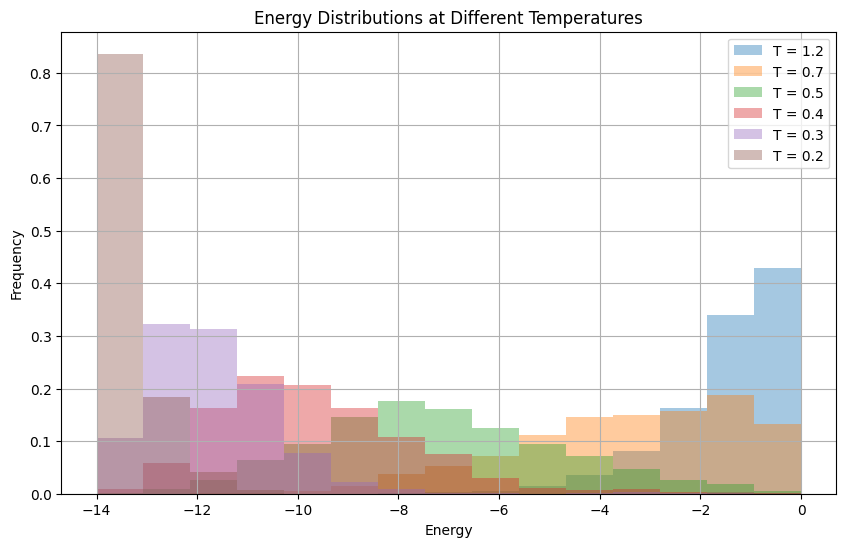

In [21]:
# Energy histogram
plt.figure(figsize=(10, 6))
bins=np.linspace(-14,0,16)
for i, T in enumerate(temperatures):
    energies = energies_per_T[T]  
    plt.hist(energies, bins=bins, alpha=0.4, 
             label=f'T = {T}', density=True)  # Aggiunto edgecolor

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distributions at Different Temperatures')
plt.legend()
plt.grid()
plt.show()

5. Given the same B blocks of moves at all βk, how does the autocorrelation in data vary with β?

Correlation functions 

In [22]:
# Correlation function for the Energies at different betas
def corr_function(O):
    t_max = len(O)
    C_t = []
    max_t = int(t_max * 0.5)
    
    for t in range(max_t):
        sum1 = 0
        sum2 = 0
        sum3 = 0
        count = t_max - t
        
        for t_prime in range(count):
            sum1 += O[t_prime] * O[t_prime + t]
            sum2 += O[t_prime]
            sum3 += O[t_prime + t]
        
        C_t.append((sum1 / count) - (sum2 / count) * (sum3 / count))
    
    if C_t[0] != 0:  
        C_t = [value / C_t[0] for value in C_t]
    
    return C_t



Plot the listed quantities as a function of β for a given N or many N’s. Do the plots meet your expectations? Is there any signature of the critical temperature?

How End-to-end distance and Last monomer height vary with temperature

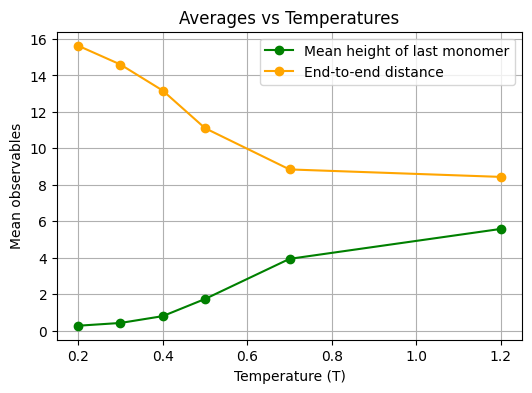

In [31]:
mean_endtoend_aftereq = {}
mean_ylast_aftereq = {}
endtoend_aftereq = {}
ylast_aftereq = {}

for T in temperatures:    
    ylast_aftereq[T] = Y_last[T][15000:] # new lists considering heights of the last monomer after a given time
    endtoend_aftereq[T] = sq_dist_perT[T][15000:] # new lists considering end-to-end distances after a given time

    average_Ylast = sum(ylast_aftereq[T]) / len(ylast_aftereq[T])
    average_endtoend = sum(endtoend_aftereq[T]) / len(endtoend_aftereq[T])

    mean_ylast_aftereq[T] = average_Ylast # filling a list of mean y last monomer
    mean_endtoend_aftereq[T] = average_endtoend # filling a list of mean end-to-end distances


plt.figure(figsize=(6,4))
plt.plot(temperatures, [mean_ylast_aftereq[T] for T in temperatures], marker='o', linestyle='-', color='green', label='Mean height of last monomer')
plt.plot(temperatures, [mean_endtoend_aftereq[T] for T in temperatures], marker='o', linestyle='-', color='orange', label = 'End-to-end distance')
plt.xlabel('Temperature (T)')
plt.ylabel('Mean observables')
plt.title('Averages vs Temperatures')
plt.legend()
plt.grid()
plt.show()

How the mean energy varies with temperature (many temperatures)

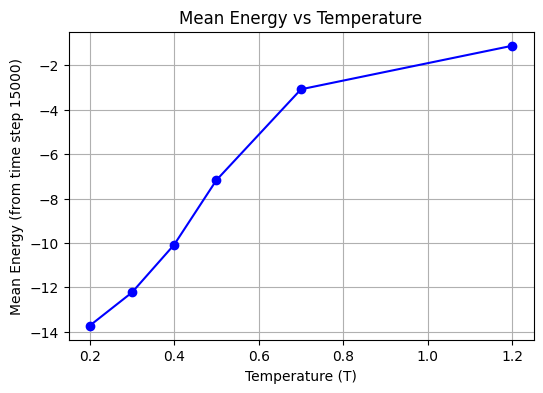

In [28]:
# Plot mean energy with respect temperatures
mean_energy_aftereq = {}
energies_aftereq = {}
for T in temperatures:    
    energies_aftereq[T] = energies_per_T[T][15000:] # new lists considering energies after a given time
    mean = sum(energies_aftereq[T]) / len(energies_aftereq[T])
    mean_energy_aftereq[T] = mean # filling a list of mean energies

plt.figure(figsize=(6,4))
plt.plot(temperatures, [mean_energy_aftereq[T] for T in temperatures], marker='o', linestyle='-', color='blue')
plt.xlabel('Temperature (T)')
plt.ylabel('Mean Energy (from time step 15000)')
plt.title('Mean Energy vs Temperature')
plt.grid()
plt.show()

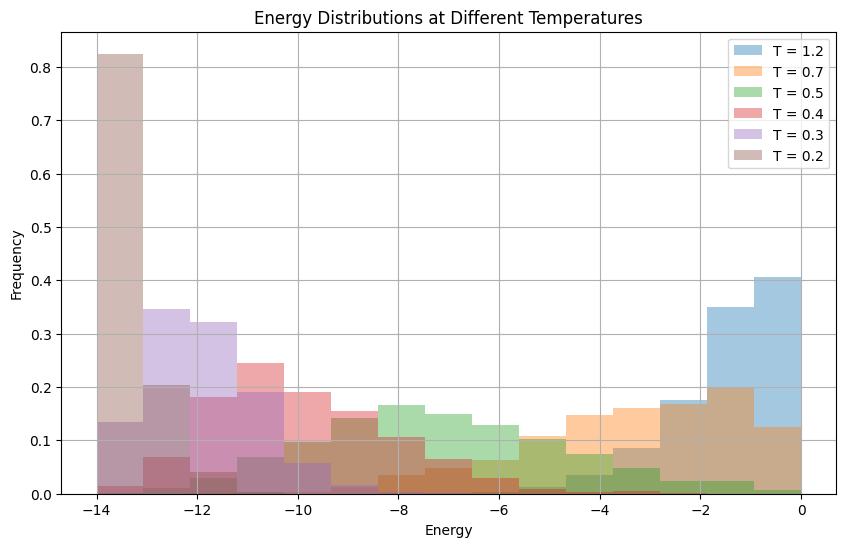

In [25]:
# Energy histogram
plt.figure(figsize=(10, 6))
bins=np.linspace(-14,0,16)
for i, T in enumerate(temperatures):
    energies = energies_aftereq[T]  
    plt.hist(energies, bins=bins, alpha=0.4, 
             label=f'T = {T}', density=True)  # Aggiunto edgecolor

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distributions at Different Temperatures')
plt.legend()
plt.grid()
plt.show()

# correlation functions

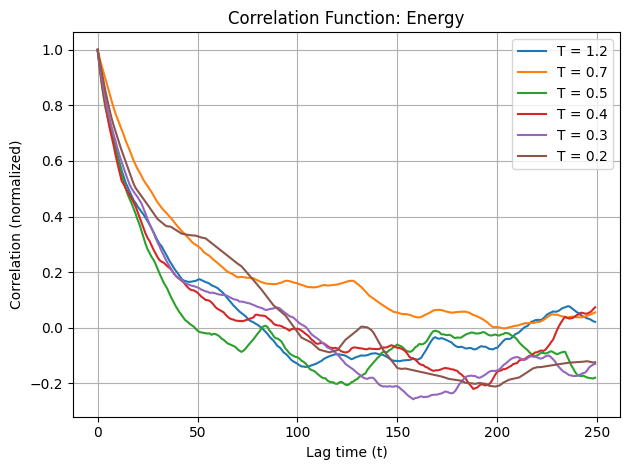

[np.float64(24.59770909657189), np.float64(46.82457732175047), np.float64(17.644182634697437), np.float64(22.158064177112674), np.float64(26.300872993408113), np.float64(35.085176158244956)]


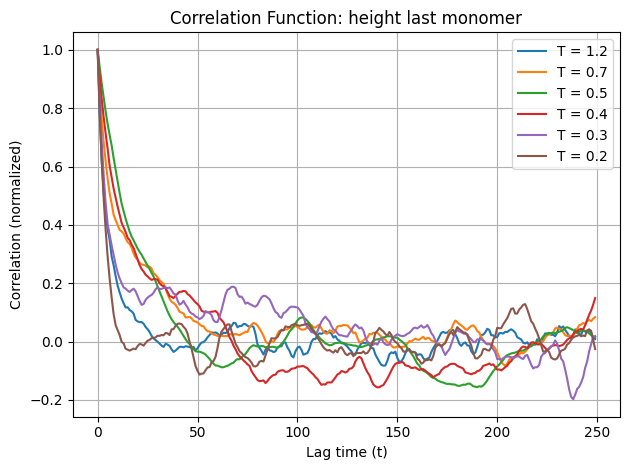

[np.float64(6.551804509559393), np.float64(16.148121668620366), np.float64(15.984556601777353), np.float64(17.99262833621129), np.float64(19.467818190184357), np.float64(4.156552632084082)]


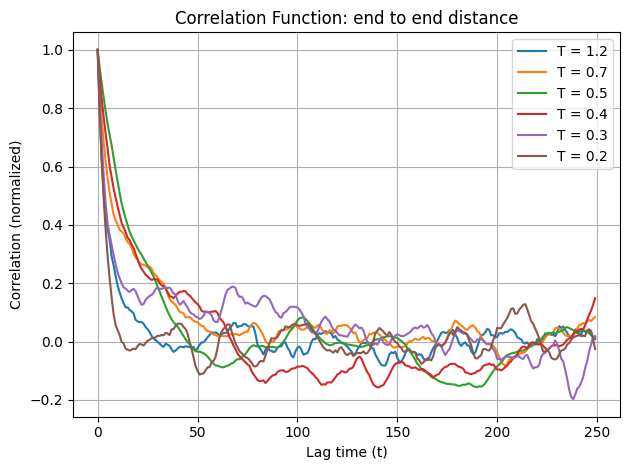

[np.float64(6.551804509559393), np.float64(16.148121668620366), np.float64(15.984556601777353), np.float64(17.99262833621129), np.float64(19.467818190184357), np.float64(4.156552632084082)]


In [34]:
# Calculate correlation for 500 time steps, then repeat and eventually do an average
sample = 500

# for the energy
corr_means = {}
taus = [] 
# for the mean height of the last monomer
corr_mh = {}
taus_mh = []
# for the end to end distance
corr_ete = {}
taus_ete = []


# ---- energy ----
for j in range(len(temperatures)): 
    C_t_list = []
    for i in range(5):
        dx = (i + 1) * sample
        sx = i * sample
        C_t_energy = corr_function(energies_aftereq[temperatures[j]][sx:dx])
        C_t_list.append(np.array(C_t_energy))

    corr_means[temperatures[j]] = np.mean(C_t_list, axis=0) # this calculate the average element by element for 5 correlation functions
    
    plt.plot(corr_means[temperatures[j]], label=f'T = {temperatures[j]}')
    t = 0
    for i in range(len(corr_means[temperatures[j]])):
        if corr_means[temperatures[j]][i] < 0:
            break
        t += corr_means[temperatures[j]][i]
    taus.append(t)

plt.xlabel('Lag time (t)')
plt.ylabel('Correlation (normalized)')
plt.title('Correlation Function: Energy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(taus)


# ---- mean height of the last monomer ----
for j in range(len(temperatures)): 
    C_t_list1 = []
    for i in range(5):
        dx = (i + 1) * sample
        sx = i * sample
        C_t_ylast = corr_function(ylast_aftereq[temperatures[j]][sx:dx])
        C_t_list1.append(np.array(C_t_ylast))

    corr_mh[temperatures[j]] = np.mean(C_t_list1, axis=0) # this calculate the average element by element for 5 correlation functions
    
    plt.plot(corr_mh[temperatures[j]], label=f'T = {temperatures[j]}')
    t = 0
    for i in range(len(corr_mh[temperatures[j]])):
        if corr_mh[temperatures[j]][i] < 0:
            break
        t += corr_mh[temperatures[j]][i]
    taus_mh.append(t)

plt.xlabel('Lag time (t)')
plt.ylabel('Correlation (normalized)')
plt.title('Correlation Function: height last monomer')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(taus_mh)

# ---- end-to-end distance ----
for j in range(len(temperatures)): 
    C_t_list2 = []
    for i in range(5):
        dx = (i + 1) * sample
        sx = i * sample
        C_t_ylast = corr_function(ylast_aftereq[temperatures[j]][sx:dx])
        C_t_list2.append(np.array(C_t_ylast))

    corr_ete[temperatures[j]] = np.mean(C_t_list2, axis=0) # this calculate the average element by element for 5 correlation functions
    
    plt.plot(corr_ete[temperatures[j]], label=f'T = {temperatures[j]}')
    t = 0
    for i in range(len(corr_ete[temperatures[j]])):
        if corr_ete[temperatures[j]][i] < 0:
            break
        t += corr_ete[temperatures[j]][i]
    taus_ete.append(t)

plt.xlabel('Lag time (t)')
plt.ylabel('Correlation (normalized)')
plt.title('Correlation Function: end to end distance')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(taus_ete)



4. Why do we use a symmetric interval [−θ∗, θ∗] in the pivot move? Should θ∗ depend on β?

# DIFFERENT ANGLES WITH PIVOT

Trying to optimize angles and shift: pi, pi greco/2, pi greco/4, pi greco/6 and see the rate of acceptance

In [ ]:
def block_pivot_pi(polymer, T):
    passed1 = 0 
    tries1 = 0 
# list to store the new positions of the monomers belonging to a rotated branch
    new_branch = [] 
    alfa = np.pi
# random postion of the pivot excluding the last monomer
    j = random.randint(0, N - 1)
    angle = random.uniform(-alfa, alfa)
    pivot = polymer[j]
 # first element of the new branch after rotation is initialized to the pivot itself
    new_branch.append(pivot) 
    E_old, E_new = 0, 0
    
# consider each monomer located after the pivot
    for k in range(j + 1, N):
    # calculation of the enrgy before the rotation:
        if polymer[k][1] < h:
            E_old -= 1
    # new coordinates after rotation:
        x_rel, y_rel = polymer[k][0] - pivot[0], polymer[k][1] - pivot[1]
        x_rot = x_rel * np.cos(angle) - y_rel * np.sin(angle)
        y_rot = x_rel * np.sin(angle) + y_rel * np.cos(angle)
    # candidate for the new, rotated monomer:
        rot_j = (pivot[0] + x_rot, pivot[1] + y_rot) 
        new_branch.append(rot_j)         

    tries1 += 1 # before even doing the tests, an attempt of rotation is done, so the number of tries is incremented of 1
    polymer1 = polymer[:j] + new_branch
         
    #Verifica la validità e aggiorna E_new se rot_j è accettabile
    for k in range(j + 1, N):    
        if valid(k, polymer1[k], polymer1) and valid_small_1(k, polymer1):
            if polymer1[1] < h:
                E_new -= 1
            
        else:
            return polymer, passed1, tries1  # Termina il passo se la rotazione non è valida

    # Test Metropolis per accettare la nuova configurazione
    if E_new < E_old or random.random() < np.exp(-(E_new - E_old) / T):
        passed1 += 1
        return polymer1, passed1, tries1
    
    return polymer, passed1, tries1




def block_pivot_pi_2(polymer, T):
# list to store the new positions of the monomers belonging to a rotated branch
    tries2 = 0
    passed2 = 0
    new_branch = [] 
    alfa = np.pi/2
# random postion of the pivot excluding the last monomer
    j = random.randint(0, N - 1)
    angle = random.uniform(-alfa, alfa)
    pivot = polymer[j]
 # first element of the new branch after rotation is initialized to the pivot itself
    new_branch.append(pivot) 
    E_old, E_new = 0, 0
    
# consider each monomer located after the pivot
    for k in range(j + 1, N):
    # calculation of the enrgy before the rotation:
        if polymer[k][1] < h:
            E_old -= 1
    # new coordinates after rotation:
        x_rel, y_rel = polymer[k][0] - pivot[0], polymer[k][1] - pivot[1]
        x_rot = x_rel * np.cos(angle) - y_rel * np.sin(angle)
        y_rot = x_rel * np.sin(angle) + y_rel * np.cos(angle)
    # candidate for the new, rotated monomer:
        rot_j = (pivot[0] + x_rot, pivot[1] + y_rot) 
        new_branch.append(rot_j)         
    
    tries2 += 1 # before even doing the tests, an attempt of rotation is done, so the number of tries is incremented of 1
    polymer1 = polymer[:j] + new_branch    
    #Verifica la validità e aggiorna E_new se rot_j è accettabile
    for k in range(j + 1, N):    
        if valid(k, polymer1[k], polymer1) and valid_small_1(k, polymer1):
            if polymer1[1] < h:
                E_new -= 1
            
        else:
            return polymer, passed2, tries2  # Termina il passo se la rotazione non è valida

    # Test Metropolis per accettare la nuova configurazione
    if E_new < E_old or random.random() < np.exp(-(E_new - E_old) / T):
        passed2 += 1
        return polymer1, passed2, tries2
    return polymer, passed2, tries2




def block_pivot_pi_4(polymer, T):
# list to store the new positions of the monomers belonging to a rotated branch
    tries3 = 0
    passed3 = 0
    new_branch = [] 
    alfa = np.pi/4
# random postion of the pivot excluding the last monomer
    j = random.randint(0, N - 1)
    angle = random.uniform(-alfa, alfa)
    pivot = polymer[j]
 # first element of the new branch after rotation is initialized to the pivot itself
    new_branch.append(pivot) 
    E_old, E_new = 0, 0
    
# consider each monomer located after the pivot
    for k in range(j + 1, N):
    # calculation of the enrgy before the rotation:
        if polymer[k][1] < h:
            E_old -= 1
    # new coordinates after rotation:
        x_rel, y_rel = polymer[k][0] - pivot[0], polymer[k][1] - pivot[1]
        x_rot = x_rel * np.cos(angle) - y_rel * np.sin(angle)
        y_rot = x_rel * np.sin(angle) + y_rel * np.cos(angle)
    # candidate for the new, rotated monomer:
        rot_j = (pivot[0] + x_rot, pivot[1] + y_rot) 
        new_branch.append(rot_j)         
    
    tries3 += 1 # before even doing the tests, an attempt of rotation is done, so the number of tries is incremented of 1
    polymer1 = polymer[:j] + new_branch    
    #Verifica la validità e aggiorna E_new se rot_j è accettabile
    for k in range(j + 1, N):    
        if valid(k, polymer1[k], polymer1) and valid_small_1(k, polymer1):
            if polymer1[1] < h:
                E_new -= 1
            
        else:
            return polymer, passed3, tries3  # Termina il passo se la rotazione non è valida

    # Test Metropolis per accettare la nuova configurazione
    if E_new < E_old or random.random() < np.exp(-(E_new - E_old) / T):
        passed3 += 1
        return polymer1, passed3, tries3
    return polymer, passed3, tries3


In [ ]:
temps = [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8] 

In [ ]:
time_steps = 30000

passed_rates_pi = {T: [] for T in temps}


for T in temps:
    tot_passed = 0 
    tot_attempts = 0
    polymer = monomers.copy() # per le 3 temperature creo dei polimeri iniziali 

    for t in range(time_steps):    
        polymer = block_shift(polymer, T)
        polymer, passed1, tries1 = block_pivot_pi(polymer, T)
        tot_passed += passed1
        tot_attempts += tries1
    
    passed_rates_pi[T].append(tot_passed/tot_attempts)
    print(passed_rates_pi[T])



[0.1048]
[0.09323333333333333]
[0.0974]
[0.1359]
[0.26953333333333335]
[0.32233333333333336]
[0.36236666666666667]


As I expect, larger angles are more likely to be accepted at high temperature, at which the chain of monomers is not as absorberd as the ones at low temperatures. 

In [ ]:
time_steps = 30000

passed_rates_pi_2 = {T: [] for T in temps}

for T in temps:
    tot_passed2 = 0 
    tot_attempts = 0
    polymer = monomers.copy() # per le 3 temperature creo dei polimeri iniziali 

    for t in range(time_steps):   
        polymer = block_shift(polymer, T)
        polymer, passed2, tries2 = block_pivot_pi_2(polymer, T)
        
        tot_passed2 += passed2
        tot_attempts += tries2
    
    passed_rates_pi_2[T].append(tot_passed2/tot_attempts)
    print(passed_rates_pi_2[T])


[0.09173333333333333]
[0.10933333333333334]
[0.11583333333333333]
[0.14506666666666668]
[0.3811]
[0.43616666666666665]
[0.4996333333333333]


In [ ]:
time_steps = 30000

passed_rates_pi_4 = {T: [] for T in temps}

for T in temps:
    tot_passed3 = 0 
    tot_attempts = 0
    polymer = monomers.copy() # per le 3 temperature creo dei polimeri iniziali 

    for t in range(time_steps):   
        polymer = block_shift(polymer, T)
        polymer, passed3, tries3 = block_pivot_pi_4(polymer, T)
        
        tot_passed3 += passed3
        tot_attempts += tries3
    
    passed_rates_pi_4[T].append(tot_passed3/tot_attempts)
    print(passed_rates_pi_4[T])

[0.13686666666666666]
[0.14506666666666668]
[0.1654]
[0.18676666666666666]
[0.4246333333333333]
[0.5189]
[0.6106]


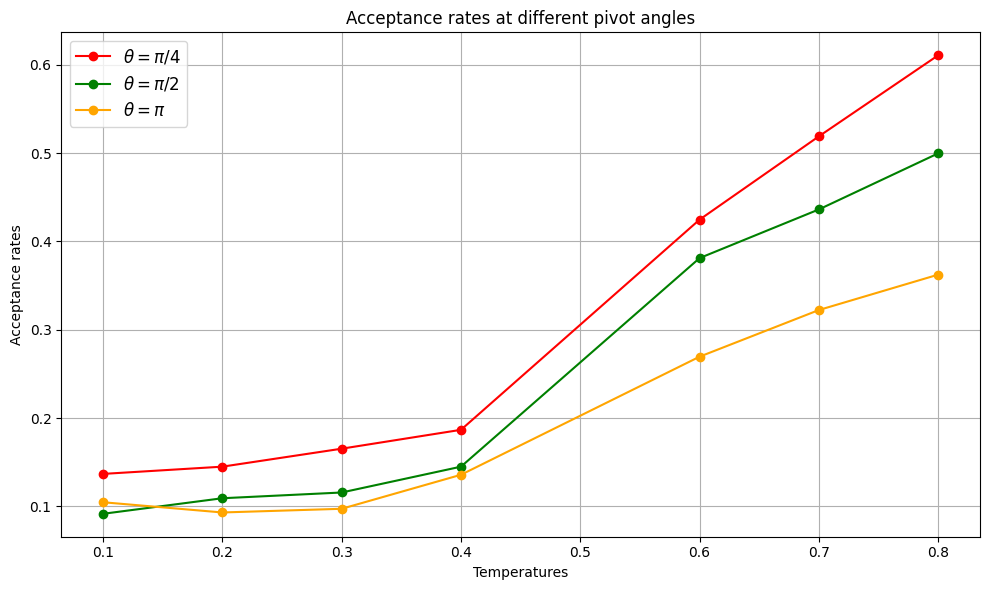

In [ ]:
# Visual representation of the rates
plt.figure(figsize=(10, 6))

plt.plot(temps, [passed_rates_pi_4[T] for T in temps], marker = 'o', color='red', label=r'$\theta = \pi/4$')
plt.plot(temps, [passed_rates_pi_2[T] for T in temps], marker = 'o', color='green', label=r'$\theta = \pi/2$')
plt.plot(temps, [passed_rates_pi[T] for T in temps], marker='o', color='orange', label=r'$\theta = \pi$')
plt.xlabel('Temperatures')
plt.ylabel('Acceptance rates')
plt.title('Acceptance rates at different pivot angles')
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

3. What did you find an appropriate distribution for the random displacements in the local shifts?

In [ ]:
temperatures = [1.0, 0.7, 0.5, 0.3, 0.2, 0.05]
temperature_indices = list(range(len(temperatures)))

In [ ]:
def block_shift_norm_1(polymer, T):
    beta = 1 / T  
    tries = 0
    passed = 0 

    for _ in range(N):
        i = random.randint(1, N - 1)
        dx, dy = np.random.normal(0, 0.15, 2) # standard deviation = 0.15
        new_mon = (polymer[i][0] + dx, polymer[i][1] + dy)
        tries += 1
        
        if valid(i, new_mon, polymer) and valid_small(i, new_mon, polymer):
            old_mon = polymer[i]  

            if test_Metropolis_shift(old_mon, new_mon, epsilon, beta):
                polymer[i] = new_mon
                passed += 1
            else:
                polymer[i] = old_mon  
    return polymer, tries, passed 
 
def block_shift_norm_2(polymer, T):
    beta = 1 / T  
    tries1 = 0 
    passed1 = 0 
    for _ in range(N):
        i = random.randint(1, N - 1)
        dx, dy = np.random.normal(0, 0.3, 2) # standard deviation = 0.3
        new_mon = (polymer[i][0] + dx, polymer[i][1] + dy)
        tries1 += 1

        if valid(i, new_mon, polymer) and valid_small(i, new_mon, polymer):
            old_mon = polymer[i]  

            if test_Metropolis_shift(old_mon, new_mon, epsilon, beta):
                polymer[i] = new_mon
                passed1 += 1
            else:
                polymer[i] = old_mon  
    return polymer, tries1, passed1 

def block_shift_norm_3(polymer, T):
    beta = 1 / T  
    tries2 = 0
    passed2 = 0
    for _ in range(N):
        i = random.randint(1, N - 1)
        dx, dy = np.random.normal(0, 0.6, 2) # standard deviation = 0.6
        new_mon = (polymer[i][0] + dx, polymer[i][1] + dy)
        tries2 += 1

        if valid(i, new_mon, polymer) and valid_small(i, new_mon, polymer):
            old_mon = polymer[i]  

            if test_Metropolis_shift(old_mon, new_mon, epsilon, beta):
                polymer[i] = new_mon
                passed2 += 1
            else:
                polymer[i] = old_mon  
    return polymer, tries2, passed2

def block_shift_unif(polymer, T):
    beta = 1 / T  
    tries3 = 0 
    passed3 = 0
    for _ in range(N):
        i = random.randint(1, N - 1)
        dx, dy = np.random.uniform(-0.2*l_max, 0.2*l_max) # uniform distribution 
        new_mon = (polymer[i][0] + dx, polymer[i][1] + dy)
        tries3 += 1

        if valid(i, new_mon, polymer) and valid_small(i, new_mon, polymer):
            old_mon = polymer[i] 
            passed3 += 1 

            if test_Metropolis_shift(old_mon, new_mon, epsilon, beta):
                polymer[i] = new_mon
            else:
                polymer[i] = old_mon  
    return polymer, tries3, passed3 

In [ ]:
time = 20000
polymer = []
rates_norm_1 = {T: [] for T in temperatures}

all_tries = {T: 0 for T in temperatures}
all_passed = {T: 0 for T in temperatures}

for i in range(len(temperatures)): # Creating an array of initial configurations, one for eache T 
        initial = monomers.copy()
        polymer.append(initial)

for  t in range(1, time + 1):
    for j in range(len(temperatures)): # For each temperature at a given time t, do the block of moves   
        T_index = temperature_indices[j]
        current_T = temperatures[j]
    # BLOCK OF MOVES
        polymer[T_index], tries, passed = block_shift_norm_1(polymer[T_index], current_T) 
        polymer[T_index] = block_pivot(polymer[T_index], current_T)

        all_passed[current_T] += passed
        all_tries[current_T] += tries

    # SWAP
    # After the block of moves is done for each temperature and for some times, I try to swap 
    if t % len(temperatures) == 0:
        k = random.randint(0, len(temperatures) - 2) 
        i = temperature_indices[k] # assegno a i l'indice della temperatura estratta
        i_next = temperature_indices[k + 1] # i_next ha l'indice della temperatura successiva a quella estratta
        T1, T2 = temperatures[k], temperatures[k + 1] # prendi le temperature estratte
        E1, E2 = total_energy(polymer[temperature_indices[k]]), total_energy(polymer[temperature_indices[k + 1]]) 

        delta = (1 / T2 - 1 / T1) * (E2 - E1)  # se T2 > T1
        
        if E2 > E1 or random.random() < np.exp(delta):  
            temperature_indices[k] = i_next
            temperature_indices[k+1] = i

for T in temperatures:
    if all_tries[T] > 0: 
        rates_norm_1[T].append(all_passed[T] / all_tries[T]) 
    else: 
        rates_norm_1[T].append(0)   

print(rates_norm_1)
    
           


{1.0: [0.40252666666666664], 0.7: [0.39999666666666667], 0.5: [0.3998333333333333], 0.3: [0.40075666666666665], 0.2: [0.39877], 0.05: [0.39618]}


In [ ]:
time = 20000
polymer = []
rates_norm_2 = {T: [] for T in temperatures}

all_tries = {T: 0 for T in temperatures}
all_passed = {T: 0 for T in temperatures}

for i in range(len(temperatures)): # Creating an array of initial configurations, one for eache T 
        initial = monomers.copy()
        polymer.append(initial)

for  t in range(1, time + 1):
    for j in range(len(temperatures)): # For each temperature at a given time t, do the block of moves   
        T_index = temperature_indices[j]
        current_T = temperatures[j]
    # BLOCK OF MOVES
        polymer[T_index], tries1, passed1 = block_shift_norm_2(polymer[T_index], current_T) 
        polymer[T_index] = block_pivot(polymer[T_index], current_T)

        all_passed[current_T] += passed1
        all_tries[current_T] += tries1

    # SWAP
    # After the block of moves is done for each temperature and for some times, I try to swap 
    if t % len(temperatures) == 0:
        k = random.randint(0, len(temperatures) - 2) 
        i = temperature_indices[k] # assegno a i l'indice della temperatura estratta
        i_next = temperature_indices[k + 1] # i_next ha l'indice della temperatura successiva a quella estratta
        T1, T2 = temperatures[k], temperatures[k + 1] # prendi le temperature estratte
        E1, E2 = total_energy(polymer[temperature_indices[k]]), total_energy(polymer[temperature_indices[k + 1]]) 

        delta = (1 / T2 - 1 / T1) * (E2 - E1)  # se T2 > T1
        
        if E2 > E1 or random.random() < np.exp(delta):  
            temperature_indices[k] = i_next
            temperature_indices[k+1] = i

for T in temperatures:
    if all_tries[T] > 0: 
        rates_norm_2[T].append(all_passed[T] / all_tries[T]) 
    else: 
        rates_norm_2[T].append(0)   

print(rates_norm_2)
    

{1.0: [0.17929], 0.7: [0.17726333333333333], 0.5: [0.17777333333333334], 0.3: [0.17622], 0.2: [0.1766], 0.05: [0.17685666666666666]}
